In [1]:
#IMPORTS

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

from utils import *
from utils2 import *

In [2]:
proj = ccrs.NorthPolarStereo()
proj_og = ccrs.PlateCarree()

## Load des données ice et air

In [3]:
dsair = xr.open_dataset('data/era5_1.nc')
dsair = dsair[['u10', 'v10']]
dsair_monthly_mean = dsair.groupby('valid_time.month').mean('valid_time')
dsair = dsair_monthly_mean
dsair

<xarray.Dataset> Size: 17MB
Dimensions:    (month: 12, latitude: 121, longitude: 1440)
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 968B 90.0 89.75 89.5 89.25 ... 60.5 60.25 60.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    u10        (month, latitude, longitude) float32 8MB 0.187 0.187 ... -3.632
    v10        (month, latitude, longitude) float32 8MB 0.1808 0.1808 ... -3.563
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

In [4]:
dsair = dsair.rename_vars({'u10': 'U', 'v10': 'V'})
dsair

<xarray.Dataset> Size: 17MB
Dimensions:    (month: 12, latitude: 121, longitude: 1440)
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 968B 90.0 89.75 89.5 89.25 ... 60.5 60.25 60.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    U          (month, latitude, longitude) float32 8MB 0.187 0.187 ... -3.632
    V          (month, latitude, longitude) float32 8MB 0.1808 0.1808 ... -3.563
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts

# Ocean currents

Idée : on se place au niveau du gyre de Beaufort pour tracer des figures de référence (Meneghello et al)

In [5]:
ds = load_climatology_with_deptho()

lon = ds.longitude
lat = ds.latitude

ds

<xarray.Dataset> Size: 1GB
Dimensions:    (month: 12, depth: 39, latitude: 121, longitude: 1440)
Coordinates:
  * depth      (depth) float32 156B 0.5058 1.556 2.668 ... 370.7 411.8 457.6
  * latitude   (latitude) float32 484B 60.0 60.25 60.5 60.75 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    S          (month, depth, latitude, longitude) float32 326MB 32.93 ... 34.88
    T          (month, depth, latitude, longitude) float32 326MB 2.22 ... 0.6027
    SIC        (month, latitude, longitude) float32 8MB 0.0008339 ... 0.982
    SIT        (month, latitude, longitude) float32 8MB 0.002912 ... 1.954
    U          (month, depth, latitude, longitude) float32 326MB -0.04629 ......
    V          (month, depth, latitude, longitude) float32 326MB 0.06839 ... ...
    SSH        (month, latitude, longitude) float32 8MB -0.08223 ... -0.5848
    deptho     (latitude, longitude) float64 1MB 2.502e+03 2.01e+03 ... nan nan
Attributes:
    history:      Creation 2023-October-31 12:55:11 GMT+0200
    source:       Copernicus Marine Service
    title:        Monthly mean fields for product GLOBAL_MULTIYEAR_PHY_ENS_00...
    references:   http://marine.copernicus.eu
    Conventions:  CF-1.6
    institution:  Mercator Ocean
    credit:       E.U. Copernicus Marine Service Information (CMEMS)
    producer:     CMEMS - Global Monitoring and Forecasting Centre
    contact:      servicedesk.cmems@mercator-ocean.eu

## Crossections

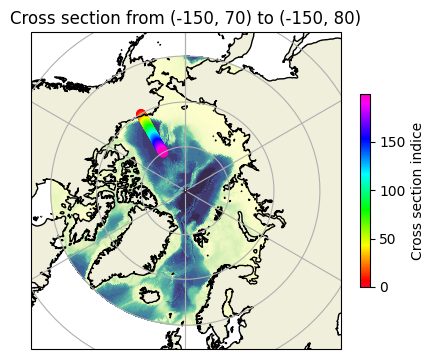

100%|██████████| 200/200 [00:02<00:00, 86.04it/s]


<xarray.Dataset> Size: 3MB
Dimensions:            (cross_section_idx: 200, month: 12, depth: 39,
                        latitude: 200, longitude: 200, dist: 200)
Coordinates:
  * depth              (depth) float32 156B 0.5058 1.556 2.668 ... 411.8 457.6
  * latitude           (latitude) float64 2kB 70.0 70.05 70.1 ... 79.95 80.0
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * longitude          (longitude) float64 2kB -150.0 -150.0 ... -150.0 -150.0
  * dist               (dist) float64 2kB 0.0 17.47 ... 3.458e+03 3.476e+03
Dimensions without coordinates: cross_section_idx
Data variables:
    S                  (cross_section_idx, month, depth) float64 749kB nan .....
    T                  (cross_section_idx, month, depth) float64 749kB nan .....
    SIC                (cross_section_idx, month) float64 19kB nan ... 0.9827
    SIT                (cross_section_idx, month) float64 19kB nan nan ... 2.021
    U                  (cross_section_idx, month, depth) float64 749kB nan .....
    V                  (cross_section_idx, month, depth) float64 749kB nan .....
    SSH                (cross_section_idx, month) float64 19kB nan ... -0.2545
    deptho             (cross_section_idx) float64 2kB nan nan ... 3.992e+03
    normal_meridional  (cross_section_idx) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
    normal_zonal       (cross_section_idx) float64 2kB -1.0 -1.0 ... -1.0 -1.0

In [6]:
lat1, lon1 = (70, -150)
lat2, lon2 = (80, -150)

#cs_dsair = cross_section(dsair, lon1, lat1, lon2, lat2, 200)

cs_ds = cross_section(ds, lon1, lat1, lon2, lat2, 200)
cs_ds

In [7]:
cs_dsair = cross_section_nodepth(dsair, lon1, lat1, lon2, lat2, 200)

cs_dsair


100%|██████████| 200/200 [00:02<00:00, 91.00it/s]


<xarray.Dataset> Size: 47kB
Dimensions:            (cross_section_idx: 200, month: 12, latitude: 200,
                        longitude: 200, dist: 200)
Coordinates:
    number             int64 8B 0
  * latitude           (latitude) float64 2kB 70.0 70.05 70.1 ... 79.95 80.0
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * longitude          (longitude) float64 2kB -150.0 -150.0 ... -150.0 -150.0
  * dist               (dist) float64 2kB 0.0 17.47 ... 3.458e+03 3.476e+03
Dimensions without coordinates: cross_section_idx
Data variables:
    U                  (cross_section_idx, month) float64 19kB -0.391 ... 0.4733
    V                  (cross_section_idx, month) float64 19kB 0.7455 ... -0....
    normal_meridional  (cross_section_idx) float64 2kB 0.0 0.0 0.0 ... 0.0 0.0
    normal_zonal       (cross_section_idx) float64 2kB -1.0 -1.0 ... -1.0 -1.0

In [8]:
vitesse = vecteurs_coupe(cs_ds)
vair = vecteurs_coupe_air(cs_dsair)

(200, 12)


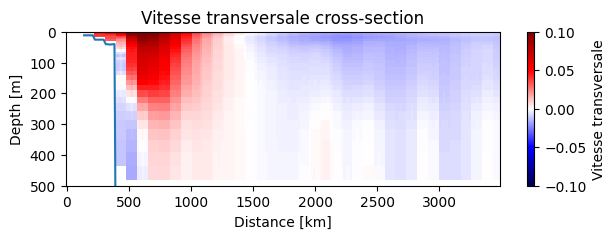

In [ ]:
ds_plot = cs_ds.sel(month=12)

cmap_min = -0.1
cmap_max = +0.1

# Vitesse transversale
fig, ax = plt.subplots(1,1,figsize=(7,2))
pc = ax.pcolormesh(ds_plot.dist, ds_plot.depth, ds_plot['vitesse transversale'].values.T, cmap='seismic',vmin=cmap_min,vmax=cmap_max)
ax.plot(ds_plot.dist, ds_plot['deptho'])
plt.colorbar(pc, ax=ax, label='Vitesse transversale')
ax.set_xlabel('Distance [km]')
ax.set_ylabel('Depth [m]')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.set_title('Vitesse transversale cross-section')
plt.show()

In [10]:
#Pour l'ocean

csvt_mean = cs_ds['vitesse transversale'].mean('depth')
csU_mean = cs_ds['U'].mean('depth')
csV_mean = cs_ds['V'].mean('depth')
Mag = np.sqrt(csU_mean**2 + csV_mean**2)

/var/folders/vk/c50yc6sn4hnb3tskwhyz__l80000gn/T/ipykernel_30701/2313582330.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  main.legend()
/var/folders/vk/c50yc6sn4hnb3tskwhyz__l80000gn/T/ipykernel_30701/2313582330.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  dev.legend()


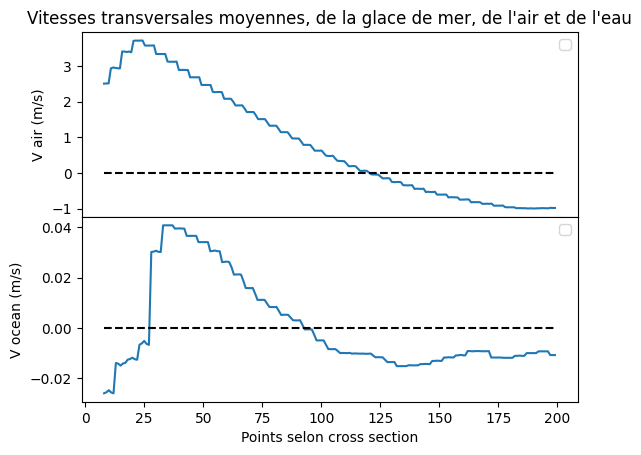

In [11]:
csvt_mean_plot = csvt_mean.sel(month = 6)
cs_dsair_plot = cs_dsair.sel(month = 6)

grid = plt.GridSpec(6, 1, hspace=0, wspace=0)
plt.style.use('default')
#plt.xkcd()
#plt.rcdefaults()
main = plt.subplot(grid[0:3], xticklabels=[])
main.plot(cs_dsair_plot['vitesse transversale'])#, c = 'b', label = 'Obs')#, linestyle = ',')
main.plot(0.*cs_dsair_plot['vitesse transversale'], c = 'black', linestyle = '--')#, linestyle = ',')
main.set_title('Vitesses transversales moyennes, de la glace de mer, de l\'air et de l\'eau')
main.set_ylabel('Vitesse transversale (m/s)')
main.set_ylabel('V air (m/s)')
main.legend()


dev = plt.subplot(grid[3:6])
dev.plot(csvt_mean_plot)#, c = 'b', label = 'Obs')#, linestyle = ',')
dev.plot(0.*csvt_mean_plot, c = 'black', linestyle = '--')#, linestyle = ',')
dev.set_ylabel('Vitesse transversale (m/s)')
dev.set_ylabel('V ocean (m/s)')
dev.set_xlabel('Points selon cross section')
dev.legend()

In [12]:
isoligne = isoligne_cross_section(cs_ds, 'S', level = 30)

In [13]:
isoligne

<xarray.Dataset> Size: 11kB
Dimensions:            (cross_section_idx: 200, month: 12)
Coordinates:
  * cross_section_idx  (cross_section_idx) int64 2kB 0 1 2 3 ... 196 197 198 199
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    depth              (cross_section_idx, month) float32 10kB 0.5058 ... 35.74

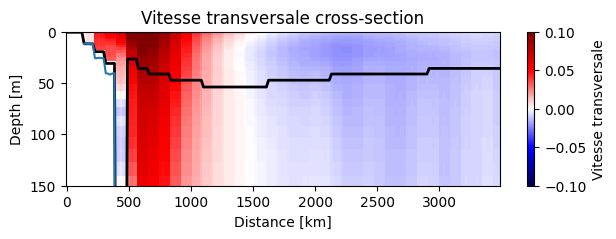

In [75]:
ds_plot = cs_ds.sel(month=12)
isoligne_plot = isoligne.sel(month=12)

cmap_min = -0.1
cmap_max = +0.1

# Vitesse transversale
fig, ax = plt.subplots(1,1,figsize=(7,2))
pc = ax.pcolormesh(ds_plot.dist, ds_plot.depth, ds_plot['vitesse transversale'].values.T, cmap='seismic',vmin=cmap_min,vmax=cmap_max)
plt.plot(ds_plot.dist, isoligne_plot['depth'].values, color='black', linewidth=2, label="Isoligne")
ax.plot(ds_plot.dist, ds_plot['deptho'])
plt.colorbar(pc, ax=ax, label='Vitesse transversale')
ax.set_xlabel('Distance [km]')
ax.set_ylabel('Depth [m]')
ax.set_ylim(0,500)
ax.invert_yaxis()
ax.set_title('Vitesse transversale cross-section')
plt.ylim(150, 0)  # Show only the top layers
plt.show()

In [20]:
ds_plot.depth.values

array([  0.50576  ,   1.5558553,   2.6676817,   3.8562799,   5.1403613,
         6.5430336,   8.092519 ,   9.82275  ,  11.77368  ,  13.991038 ,
        16.525322 ,  19.429802 ,  22.757616 ,  26.5583   ,  30.874561 ,
        35.740204 ,  41.180023 ,  47.211895 ,  53.850636 ,  61.11284  ,
        69.02168  ,  77.61116  ,  86.92943  ,  97.04131  , 108.03028  ,
       120.       , 133.07582  , 147.40625  , 163.16446  , 180.54993  ,
       199.78996  , 221.14117  , 244.89062  , 271.35638  , 300.8875   ,
       333.86282  , 370.68848  , 411.79385  , 457.6256   ], dtype=float32)